In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df=pd.read_csv('/content/seasonal_agriculture_performance_dataset.csv')

In [ ]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [ ]:
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [ ]:
df.shape

(4000, 28)

In [ ]:
df.columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [ ]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [ ]:
missing_percentage =(df.isnull().sum()/len(df))*100
missing_percentage[missing_percentage > 0]


,0
Rainfall_mm,1.2
Soil_Moisture_pct,1.0
Yield_Tonnes_Ha,0.8


In [ ]:

df['Soil_Moisture_pct']=df.groupby('Season')['Soil_Moisture_pct'].transform(
    lambda x:x.fillna(x.median())
)
df['Yield_Tonnes_Ha']=df.groupby('Season')['Yield_Tonnes_Ha'].transform(
    lambda x:x.fillna(x.median())
)

In [ ]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [ ]:
df['Rainfall_mm'].isnull().sum()

np.int64(48)

In [ ]:
df['Rainfall_mm']=df.groupby('Season')['Rainfall_mm'].transform(
    lambda x:x.fillna(x.median())
)

In [ ]:
df['Rainfall_mm'].isnull().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,0
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
categorical_columns = ['State', 'District', 'Crop', 'Season', 'Irrigation_Method']

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())
    print("Number of unique values:", df[column].nunique())


State:
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']
Number of unique values: 8

District:
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']
Number of unique values: 10

Crop:
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']
Number of unique values: 8

Season:
['Kharif' 'Rabi' 'Zaid']
Number of unique values: 3

Irrigation_Method:
['Drip' 'Flood' 'Rainfed' 'Sprinkler']
Number of unique values: 4


### Categorical Variable Analysis

The dataset contains 8 states, 10 districts, 8 crop types, 3 agricultural seasons, and 4 irrigation methods.

The three seasons present in the dataset are Kharif, Rabi, and Zaid. Since the objective of this project is to analyze seasonal agricultural performance, the Season variable will be used as the primary grouping variable for comparing environmental conditions, agricultural production, resource usage, and economic performance.

#Descriptive Statistics

In [ ]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,600.714313,26.81890,63.210500,7.323050,6.701010,26.504525,120.250825,57.781850,104.760050,...,0.826138,5.241955,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.427366,3.81818,11.960834,1.121186,0.641461,6.696998,31.216452,17.015074,27.742681,...,0.101747,13.311661,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.425000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,581.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.730000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,836.125000,29.60000,71.900000,8.100000,7.140000,31.200000,141.225000,69.400000,123.600000,...,0.910000,2.830000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


### Descriptive Statistics

Descriptive statistics were calculated to understand the central tendency and variation of the numerical variables.

The dataset shows considerable variation in environmental conditions, farm size, agricultural production, economic outcomes, and resource usage. The average farm area is approximately 7.89 hectares, while the average rainfall is approximately 600.71 mm.

The mean agricultural yield is approximately 5.24 tonnes per hectare. However, the median yield is substantially lower than the mean, suggesting that some high-value observations may influence the average yield.

Economic outcomes also show considerable variation. Profit ranges from negative values, representing financial losses, to high positive values. Further analysis will investigate seasonal differences and potential unusual observations.

In [ ]:
df['Season'].value_counts()

,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


### Season Distribution

The dataset contains 1779 Kharif records, 1627 Rabi records, and 594 Zaid records. The distribution of records is not equal across the three seasons.

Therefore, seasonal performance comparisons will primarily use average values rather than total values to ensure that differences in the number of observations do not unfairly influence the analysis.

In [ ]:
df['Crop'].value_counts()

,count
Crop,
Rice,690
Wheat,614
Maize,551
Cotton,508
Pulses,496
Groundnut,424
Chilli,412
Sugarcane,305


### Crop Distribution

The dataset contains 8 different crop types. Rice has the highest number of records (690), while Sugarcane has the lowest number of records (305).

Since different crops can have different yield levels, production patterns, market prices, and resource requirements, crop type will be considered when interpreting seasonal agricultural performance.

In [ ]:
import pandas as pd
df=pd.read_csv('/content/seasonal_agriculture_performance_dataset.csv')
print("Dataset uploaded successfull")
print("Rows:",df.shape[0])
print("columns:",df.shape[1])

Dataset uploaded successfull
Rows: 4000
columns: 28


In [ ]:
print(df['Yield_Tonnes_Ha'].describe())
print("\nMissing values:", df['Yield_Tonnes_Ha'].isna().sum())
print("Number of values:", df['Yield_Tonnes_Ha'].count())

count    3968.000000
mean        5.270595
std        13.361398
min         0.300000
25%         1.050000
50%         1.740000
75%         2.840000
max       101.440000
Name: Yield_Tonnes_Ha, dtype: float64

Missing values: 32
Number of values: 3968


In [ ]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [ ]:
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(df['Rainfall_mm'].median())

df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(
    df['Soil_Moisture_pct'].median()
)

df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(
    df['Yield_Tonnes_Ha'].median()
)

In [ ]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,0
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [ ]:
columns = ['Yield_Tonnes_Ha', 'Production_Tonnes', 'Profit_INR', 'Water_Used_m3']

for column in columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    print("\nColumn:", column)
    print("Lower limit:", round(lower, 2))
    print("Upper limit:", round(upper, 2))
    print("Number of outliers:", len(outliers))


Column: Yield_Tonnes_Ha
Lower limit: -1.62
Upper limit: 5.5
Number of outliers: 302

Column: Production_Tonnes
Lower limit: -23.98
Upper limit: 53.36
Number of outliers: 333

Column: Profit_INR
Lower limit: -696111.0
Upper limit: 763567.0
Number of outliers: 404

Column: Water_Used_m3
Lower limit: -6072.75
Upper limit: 16171.25
Number of outliers: 276


In [ ]:
columns = ['Yield_Tonnes_Ha', 'Production_Tonnes', 'Profit_INR', 'Water_Used_m3']

for column in columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    upper = Q3 + 1.5 * IQR

    outliers = df[df[column] > upper]

    print("\n", column)
    print(outliers[column].describe())


 Yield_Tonnes_Ha
count    302.000000
mean      47.151656
std       20.831451
min        5.590000
25%       32.672500
50%       48.255000
75%       61.932500
max      101.440000
Name: Yield_Tonnes_Ha, dtype: float64

 Production_Tonnes
count     333.000000
mean      366.591201
std       279.345039
min        53.440000
25%       112.870000
50%       313.980000
75%       562.670000
max      1424.400000
Name: Production_Tonnes, dtype: float64

 Profit_INR
count    3.530000e+02
mean     1.488619e+06
std      6.662451e+05
min      7.640020e+05
25%      9.611400e+05
50%      1.255583e+06
75%      1.870843e+06
max      4.345421e+06
Name: Profit_INR, dtype: float64

 Water_Used_m3
count      276.000000
mean     21807.217391
std       4281.558407
min      16215.000000
25%      18300.250000
50%      21123.000000
75%      24389.750000
max      40902.000000
Name: Water_Used_m3, dtype: float64


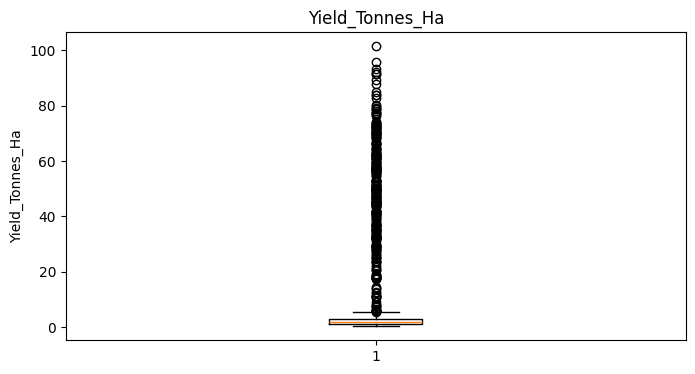

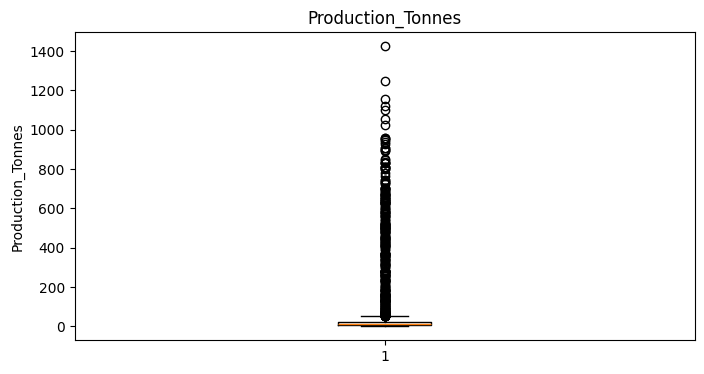

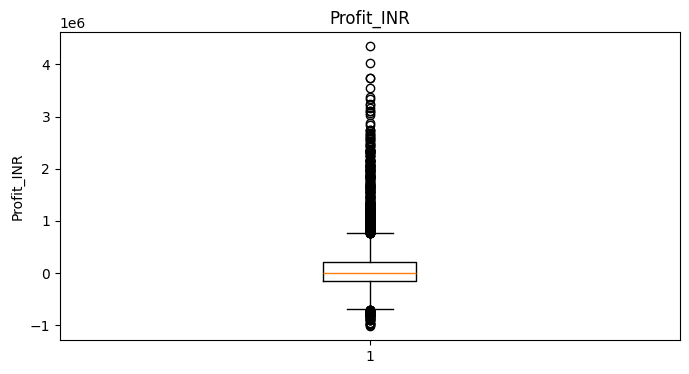

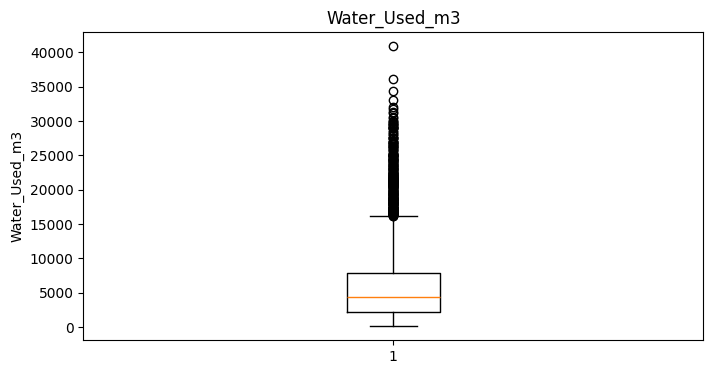

In [ ]:
import matplotlib.pyplot as plt

columns = ['Yield_Tonnes_Ha', 'Production_Tonnes', 'Profit_INR', 'Water_Used_m3']

for column in columns:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[column])
    plt.title(column)
    plt.ylabel(column)
    plt.show()

What the graphs show
Yield: Many values appear above the upper limit, with some very high yields.
Production: Several high-production observations are visible.
Profit: There are both high positive and some negative extreme values.
Water Used: Several observations have unusually high water usage.

Outlier Investigation

I used boxplots and the IQR method to find possible outliers in yield, production, profit, and water usage. I checked these unusual values but did not remove them, as they could be genuine differences between farms rather than errors. So, the original values were kept for the analysis.


In [ ]:
columns = df.select_dtypes(include='number').columns

for column in columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    print(column, ":", len(outliers))

Farm_Area_Hectares : 0
Rainfall_mm : 0
Avg_Temperature_C : 2
Humidity_pct : 6
Sunlight_Hours_Day : 26
Soil_pH : 0
Soil_Moisture_pct : 5
Nitrogen_kg_ha : 10
Phosphorus_kg_ha : 16
Potassium_kg_ha : 32
Fertilizer_kg_ha : 15
Pesticide_Litre_ha : 8
Seed_Quality_Score : 0
Yield_Tonnes_Ha : 302
Production_Tonnes : 333
Market_Price_INR_Tonne : 0
Total_Cost_INR : 0
Revenue_INR : 240
Profit_INR : 404
Water_Used_m3 : 276
Water_Efficiency_t_per_1000m3 : 322
Disease_Pest_Risk_pct : 10


I used the IQR method to check for outliers in all the numerical variables. More potential outliers were found in yield, production, profit, water usage, and water efficiency. These values were not removed because they could represent real differences between farms rather than errors in the data.

UNIVARIATE ANALYSIS

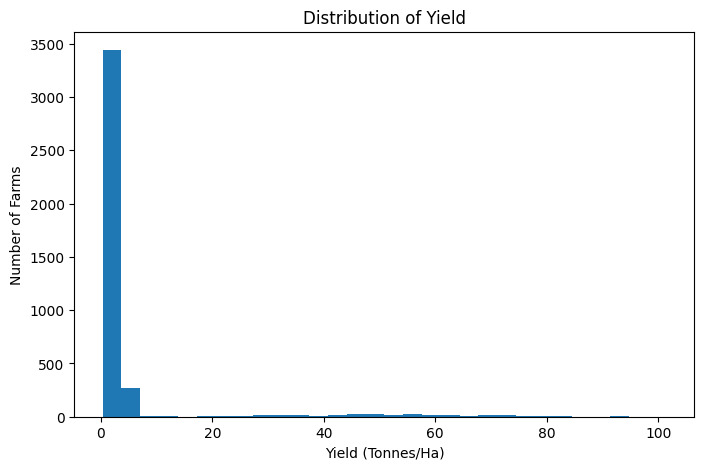

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df['Yield_Tonnes_Ha'], bins=30)
plt.title('Distribution of Yield')
plt.xlabel('Yield (Tonnes/Ha)')
plt.ylabel('Number of Farms')
plt.show()

Yield Analysis:
The yield values are mostly concentrated at the lower end, while a small number of farms have much higher yields. This makes the distribution right-skewed and shows that yield varies considerably across the farms.

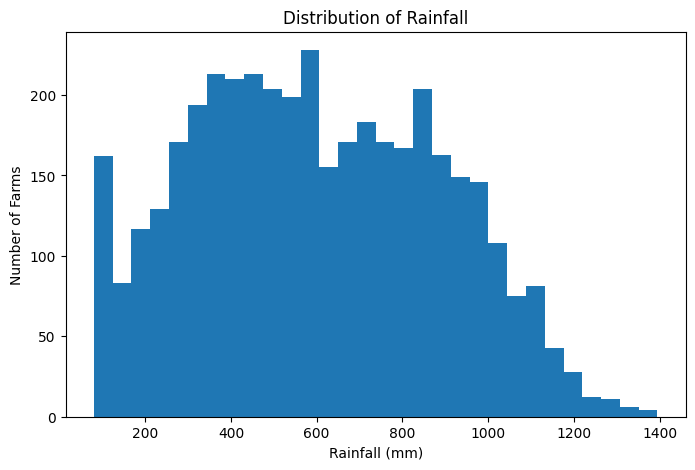

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df['Rainfall_mm'], bins=30)
plt.title('Distribution of Rainfall')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Number of Farms')
plt.show()

Rainfall Analysis:
Rainfall varies quite a lot across the farms. Most of the rainfall values are between around 300 and 1000 mm, while only a few farms have very high rainfall. This shows that the farms experience different rainfall conditions.

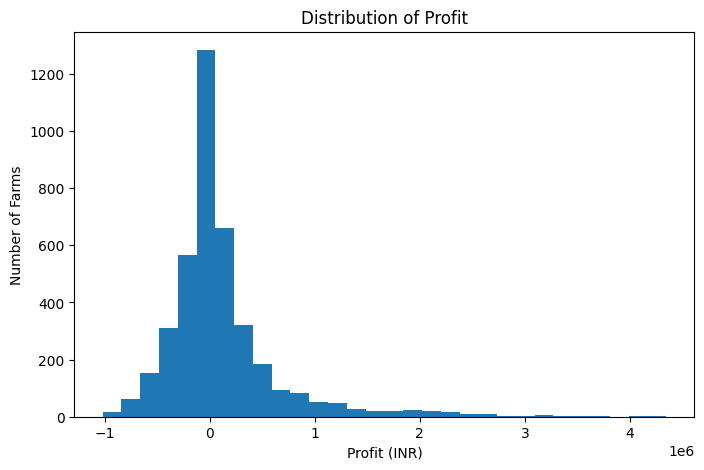

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df['Profit_INR'], bins=30)
plt.title('Distribution of Profit')
plt.xlabel('Profit (INR)')
plt.ylabel('Number of Farms')
plt.show()

Profit Analysis:
Most farms have profit close to the lower range, while some farms have negative profit and a few have very high profit. This shows that profitability varies considerably across the farms.

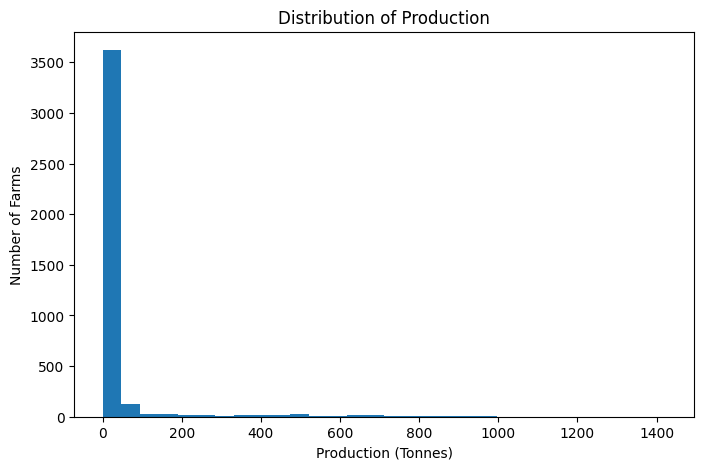

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df['Production_Tonnes'], bins=30)
plt.title('Distribution of Production')
plt.xlabel('Production (Tonnes)')
plt.ylabel('Number of Farms')
plt.show()

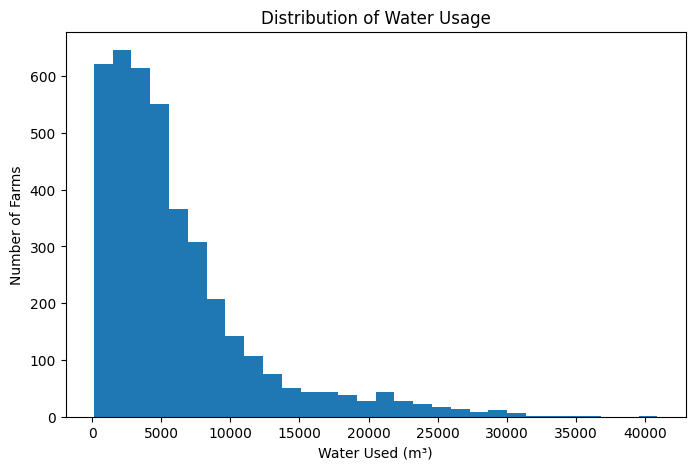

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df['Water_Used_m3'], bins=30)
plt.title('Distribution of Water Usage')
plt.xlabel('Water Used (m³)')
plt.ylabel('Number of Farms')
plt.show()

# BIVARIATE ANALYSIS

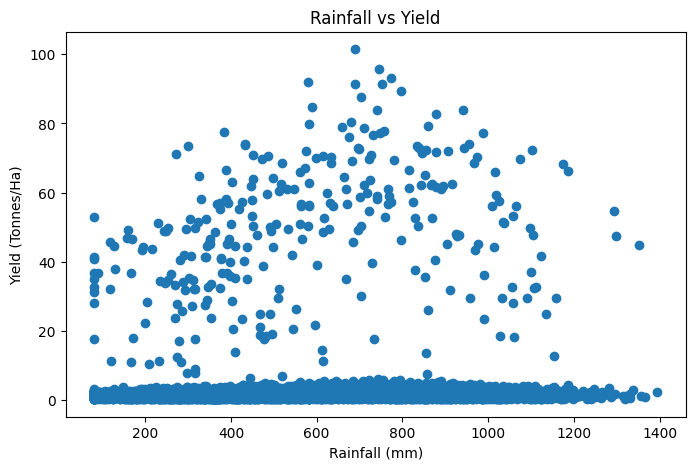

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Rainfall_mm'], df['Yield_Tonnes_Ha'])
plt.title('Rainfall vs Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

Rainfall vs Yield:
Most of the farms are grouped in the lower yield range across different rainfall levels. A few farms have much higher yields, but the points are quite spread out. This suggests that rainfall alone does not fully explain the differences in yield, and other factors may also play a role.

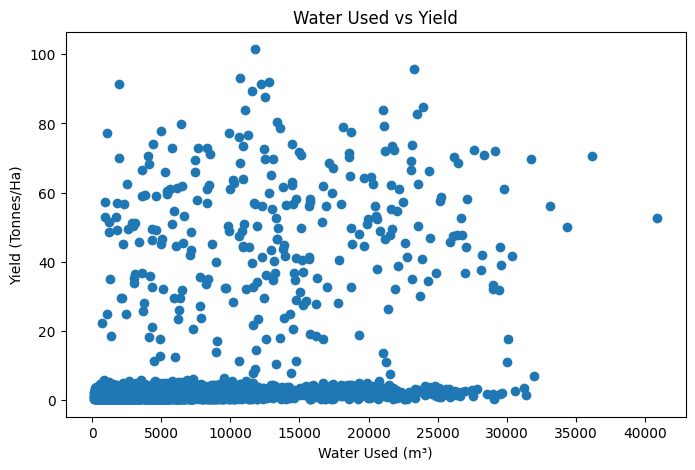

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Water_Used_m3'], df['Yield_Tonnes_Ha'])
plt.title('Water Used vs Yield')
plt.xlabel('Water Used (m³)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

Water Used vs Yield:
Most of the farms are grouped in the lower yield range, even when the amount of water used is different. A few farms have much higher yields and higher water usage. The points are quite scattered, so water usage alone does not clearly explain the differences in yield.

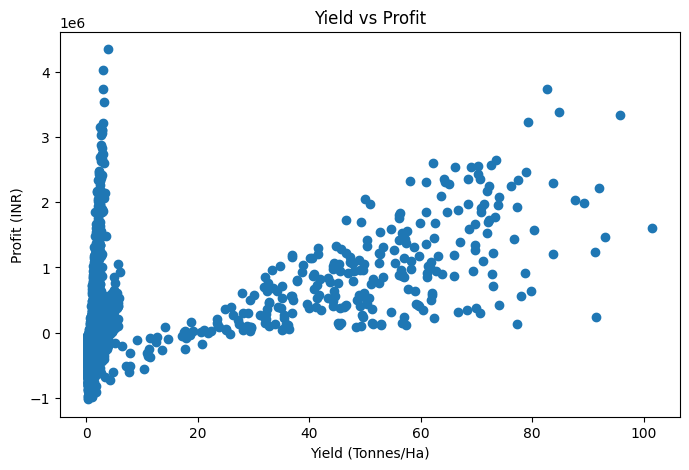

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Yield_Tonnes_Ha'], df['Profit_INR'])
plt.title('Yield vs Profit')
plt.xlabel('Yield (Tonnes/Ha)')
plt.ylabel('Profit (INR)')
plt.show()

Yield vs Profit: Most farms have lower yield and their profit values are spread across a wide range. Some farms with higher yield also show higher profit, but the points are scattered. This suggests that higher yield may contribute to higher profit, but profit is also affected by other factors such as production cost and market price.

In [ ]:
season_crop_yield = df.groupby(['Season', 'Crop'])['Yield_Tonnes_Ha'].mean().unstack()

season_crop_yield

Crop,Chilli,Cotton,Groundnut,Maize,Pulses,Rice,Sugarcane,Wheat
Season,,,,,,,,
Kharif,1.731459,1.374512,1.484974,2.966410,1.036063,2.698376,53.459120,2.253664
Rabi,1.465031,1.198358,1.233164,2.603648,0.875962,2.322847,43.286124,2.057468
Zaid,1.195312,0.960217,1.037778,2.290952,0.669677,1.900490,38.423922,1.748588


Multivariate Analysis: I compared yield across different crops and seasons at the same time. The results show that Kharif generally has the highest average yield, followed by Rabi and Zaid. Sugarcane has the highest yield across all seasons, while Pulses has the lowest. This shows that both crop type and season can influence agricultural performance.

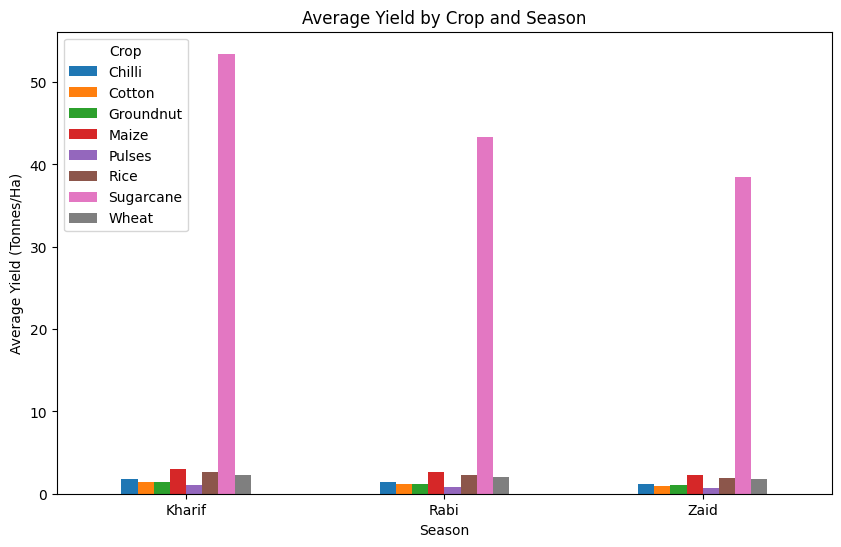

In [ ]:
season_crop_yield.plot(kind='bar', figsize=(10, 6))

plt.title('Average Yield by Crop and Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=0)
plt.legend(title='Crop')
plt.show()

Multivariate Analysis: I compared the average yield of different crops across Kharif, Rabi, and Zaid seasons. Sugarcane has the highest average yield in all three seasons, while the other crops have much lower yields. This shows that crop type has a strong difference in average yield, and the seasonal comparison also shows that yield changes across seasons.

Correlation analysis

In [ ]:
correlation = df.corr(numeric_only=True)

correlation

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Farm_Area_Hectares,1.000000,0.007256,0.036870,0.000471,0.001821,0.009857,0.004033,0.013658,-0.006625,0.000195,...,0.015236,0.030203,0.197842,-0.021571,0.962211,0.543364,0.115241,0.576015,0.028930,0.025963
Rainfall_mm,0.007256,1.000000,0.198492,0.521069,-0.362779,0.016657,0.508941,0.007460,0.020940,0.031373,...,-0.018581,0.030951,0.024447,0.000639,0.013041,0.098146,0.107648,0.002240,0.058102,0.621762
Avg_Temperature_C,0.036870,0.198492,1.000000,0.138136,-0.033863,0.029988,0.084001,0.018707,0.008508,0.022993,...,-0.031943,0.009996,0.007346,0.002951,0.041030,0.026703,0.009043,0.022995,0.006534,0.245613
Humidity_pct,0.000471,0.521069,0.138136,1.000000,-0.297298,0.028447,0.446470,0.001198,-0.005963,-0.003070,...,-0.045598,0.012297,0.003614,0.000262,0.006023,0.057358,0.063775,-0.002086,0.026169,0.545093
Sunlight_Hours_Day,0.001821,-0.362779,-0.033863,-0.297298,1.000000,-0.017806,-0.302846,0.009920,0.001544,-0.014407,...,0.021257,-0.015341,-0.023504,-0.000696,-0.000655,-0.047216,-0.054822,-0.005717,-0.021386,-0.253251
Soil_pH,0.009857,0.016657,0.029988,0.028447,-0.017806,1.000000,0.031183,0.006286,0.016620,-0.019407,...,-0.004181,-0.020672,-0.012512,0.022226,0.005302,-0.008798,-0.013145,-0.022859,-0.010087,0.031141
Soil_Moisture_pct,0.004033,0.508941,0.084001,0.446470,-0.302846,0.031183,1.000000,0.008884,0.013406,0.007796,...,-0.019556,0.010999,0.004787,0.016914,0.002741,0.079380,0.091281,0.003183,0.027776,0.375547
Nitrogen_kg_ha,0.013658,0.007460,0.018707,0.001198,0.009920,0.006286,0.008884,1.000000,0.010199,0.010490,...,0.014896,0.053149,0.048182,-0.022595,0.011900,0.078252,0.085016,0.022127,0.054896,-0.011503
Phosphorus_kg_ha,-0.006625,0.020940,0.008508,-0.005963,0.001544,0.016620,0.013406,0.010199,1.000000,0.002847,...,-0.007575,0.047941,0.034957,-0.005174,-0.016508,0.034940,0.049747,-0.000752,0.057129,0.032061
Potassium_kg_ha,0.000195,0.031373,0.022993,-0.003070,-0.014407,-0.019407,0.007796,0.010490,0.002847,1.000000,...,0.006862,0.003382,0.004472,0.007572,0.003431,0.028278,0.031192,0.001667,0.006575,0.013403


Correlation Analysis: The correlation analysis shows that some agricultural variables have strong relationships with each other. Yield has a strong positive relationship with water efficiency and production, while profit has a strong positive relationship with revenue. Yield also has a moderate positive relationship with profit and water usage. Rainfall shows a positive relationship with disease and pest risk. Overall, the results show that agricultural performance is influenced by several related factors rather than by one factor alone.

In [ ]:
season_summary = df.groupby('Season')[[
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Profit_INR',
    'Water_Used_m3',
    'Water_Efficiency_t_per_1000m3'
]].mean()

season_summary

,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,,,,
Kharif,5.628612,46.311192,178914.647555,6102.201237,5.891834
Rabi,5.039435,41.486712,87689.470191,5846.987093,5.186122
Zaid,4.641313,38.886111,-24804.824916,6419.893939,4.413239


Seasonal Comparison: Kharif shows the strongest overall agricultural performance, with the highest average yield, production, profit, and water efficiency. Rabi shows moderate performance, while Zaid records the lowest yield, production, profit, and water efficiency. Zaid also uses the most water on average, suggesting that higher water usage does not necessarily lead to better performance.

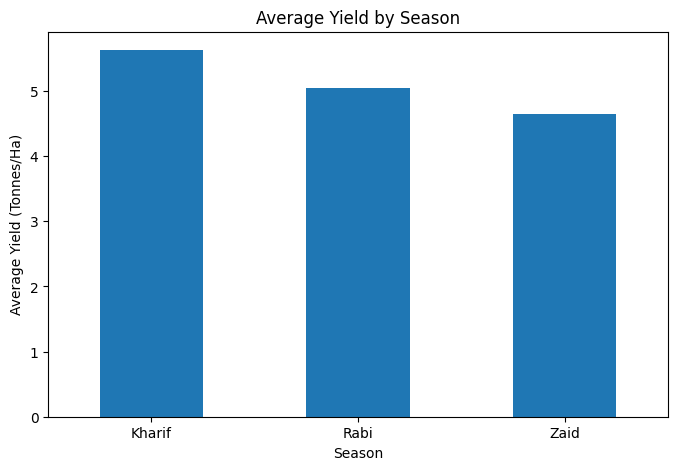

In [ ]:
season_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean()

season_yield.plot(kind='bar', figsize=(8, 5))

plt.title('Average Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=0)
plt.show()

In [ ]:
season_environment = df.groupby('Season')[[
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_Moisture_pct'
]].mean()

season_environment

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,849.199663,28.454019,71.812591,6.793367,31.149859
Rabi,437.615366,23.489183,57.893178,7.589797,24.069392
Zaid,304.654714,31.042088,52.012121,8.178788,19.279630


Seasonal Environmental Comparison: Kharif has the highest rainfall, humidity, and soil moisture, while Zaid has the highest temperature and sunlight hours. Rabi generally has moderate environmental conditions. These differences show that environmental conditions vary considerably across seasons and may contribute to differences in agricultural performance.

In [ ]:
crop_season = df.groupby(['Crop', 'Season'])['Yield_Tonnes_Ha'].mean().unstack()

crop_season

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.731459,1.465031,1.195312
Cotton,1.374512,1.198358,0.960217
Groundnut,1.484974,1.233164,1.037778
Maize,2.966410,2.603648,2.290952
Pulses,1.036063,0.875962,0.669677
Rice,2.698376,2.322847,1.900490
Sugarcane,53.459120,43.286124,38.423922
Wheat,2.253664,2.057468,1.748588


Crop-wise Seasonal Comparison: The analysis shows that Kharif has the highest average yield for all crops, followed by Rabi and Zaid. Sugarcane records the highest yield across all three seasons, while Pulses has the lowest. The consistent decrease from Kharif to Zaid across crops indicates that seasonal conditions may have an important influence on crop performance.

Does the irrigation method have an effect on average yield and water efficiency?

In [ ]:
irrigation_analysis = df.groupby('Irrigation_Method')[[
    'Yield_Tonnes_Ha',
    'Water_Efficiency_t_per_1000m3'
]].mean()

irrigation_analysis

,Yield_Tonnes_Ha,Water_Efficiency_t_per_1000m3
Irrigation_Method,,
Drip,6.577989,6.267129
Flood,4.863977,3.438853
Rainfed,4.602142,7.563784
Sprinkler,5.160627,4.669805


Irrigation Analysis: Drip irrigation has the highest average yield, while Rainfed farming has the highest water efficiency. Flood irrigation records both lower yield and the lowest water efficiency. This shows that irrigation methods can have different effects on productivity and water efficiency

Which crops generate the highest average profit?

In [ ]:
crop_profit = df.groupby('Crop')['Profit_INR'].mean().sort_values(ascending=False)

crop_profit

,Profit_INR
Crop,
Sugarcane,817187.986885
Chilli,750878.342233
Cotton,124546.915354
Groundnut,44858.120283
Pulses,-4238.052419
Maize,-83978.326679
Rice,-102213.504348
Wheat,-123398.337134


Crop Profitability Analysis: Sugarcane and Chilli show the highest average profits, while Maize, Rice, and Wheat have negative average profits. This shows that economic performance differs considerably between crops and that some crops may require better cost management or market conditions to remain profitable.

Is disease and pest risk related to crop yield?

In [ ]:
risk_yield = df[['Disease_Pest_Risk_pct', 'Yield_Tonnes_Ha']].corr()

risk_yield

,Disease_Pest_Risk_pct,Yield_Tonnes_Ha
Disease_Pest_Risk_pct,1.000000,0.014292
Yield_Tonnes_Ha,0.014292,1.000000


Disease/Pest Risk Analysis: The correlation between disease/pest risk and yield is 0.014, which is very close to zero. This suggests that there is almost no linear relationship between disease/pest risk and yield in the dataset.


8 Meaningful Insights

1. Kharif season performed the best overall.
   Kharif had the highest average yield, production, profit, and water efficiency compared with Rabi and Zaid.

2. Zaid season showed the weakest performance.
   Zaid had the lowest average yield and production, and it also had a negative average profit. This shows that farming during Zaid was less profitable in the given dataset.

3. The environmental conditions were quite different across     seasons.
   Kharif received much more rainfall and had higher humidity and soil moisture. On the other hand, Zaid was hotter and had more sunlight but much less rainfall and soil moisture.

4. Using more water did not always mean getting better results.
   Zaid used the highest amount of water on average, but still had the lowest yield and water efficiency. So, simply increasing water usage does not guarantee better agricultural performance.

5. Sugarcane had much higher yields than the other crops.
   Sugarcane was the highest-yielding crop in Kharif, Rabi, and Zaid. Its yield was much higher than the other crops in every season.

6. Drip irrigation gave the highest average yield.
   Farms using drip irrigation had an average yield of about 6.58 tonnes/ha**, which was higher than the other irrigation methods.

7. The most water-efficient method was not the highest-yielding method.
   Rainfed farming had the highest water efficiency, even though it had the lowest average yield. This shows that yield and water efficiency do not always increase together.

8. Profitability was very different from one crop to another.
   Sugarcane and Chilli had the highest average profits, while Wheat, Rice, and Maize had negative average profits. This suggests that crop selection can have a major impact on the economic outcome of farming.

 Extra insight

The analysis also showed that disease and pest risk had almost no linear relationship with yield in this dataset, with a correlation of only 0.014.


Recommendations: Based on the analysis, greater focus can be given to Kharif farming because it showed better overall performance. Zaid farming may require more careful planning because of its lower yield, water efficiency, and negative average profit. Drip irrigation can be considered when higher yield is the main objective, while Rainfed farming showed better water efficiency. Crop selection should also consider both yield and profitability, along with the environmental conditions of each season.

**Limitations**: This analysis is based on the available 4,000 farm records and may not represent all agricultural regions or farming conditions. Some missing values were present and were handled during data cleaning. A few variables also contained unusual values, which were retained because they could represent genuine farm-level differences. The analysis mainly identifies patterns and relationships in the data, so correlation should not be interpreted as proof of cause and effect. Other factors not included in the dataset may also influence agricultural performance.

**Final Conclusion:**
This project analyzed agricultural performance across Kharif, Rabi, and Zaid seasons using different factors such as yield, production, environmental conditions, water usage, and profit. The analysis showed that Kharif generally had the best overall performance, while Zaid had lower yield, lower water efficiency, and negative average profit. Environmental conditions also varied considerably between seasons, which may contribute to differences in agricultural performance. Crop and irrigation analysis showed that crop choice and irrigation method can also make a noticeable difference in yield and profitability. Overall, the findings can help in making better seasonal decisions about crop selection, irrigation, resource usage, and farm planning.